In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
import h5py
train_dataset = h5py.File(r'E:\Pyhton code\Data Sets\archive\Cat vs Non Cat\train_catvnoncat.h5')
test_dataset = h5py.File(r'E:\Pyhton code\Data Sets\archive\Cat vs Non Cat\test_catvnoncat.h5')

In [6]:
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y = np.array(train_dataset["train_set_y"][:])

test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y = np.array(test_dataset["test_set_y"][:])

classes = np.array(test_dataset["list_classes"][:])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

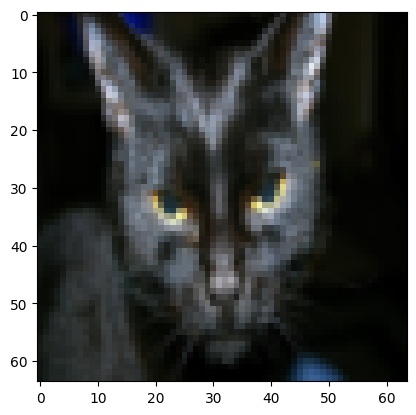

In [7]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

In [8]:
m_train = train_set_y_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (209,)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (50,)


In [17]:
#Flatten data
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0],-1).T 
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0],-1).T 
train_set_y = train_set_y.reshape(1,-1)
test_set_y = test_set_y.reshape(1,-1)
print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [18]:
#standardize dataset
train_set_x = train_set_x_flatten / 255
test_set_x = test_set_x_flatten / 255

In [41]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [42]:
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

[0.62245933 0.5        0.88079708]


In [43]:
#Initialize Parameters
def initialize_with_zeros(dim):
    W = np.zeros((dim,1))
    b = 0.0
    return W,b

In [44]:
dim = 2
w, b = initialize_with_zeros(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0.0


In [63]:
#Forward Propagation
def propagate(w,b,X,Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -(1/m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    dw = (1/m) * np.dot(X, (A-Y).T)
    db = (1/m) * np.sum(A-Y)
    
    cost = np.squeeze(np.array(cost))
    grads = {"dw":dw, "db":db}
    
    return grads, cost

In [64]:
w =  np.array([[1.], [2]])
b = 1.5

# X is using 3 examples, with 2 features each
# Each example is stacked column-wise
X = np.array([[1., -2., -1.], [3., 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
grads, cost = propagate(w, b, X, Y)

assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64


print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.1250040450043965
cost = 0.15900537707692405


In [65]:
import copy

In [66]:
#Optimize
def optimize(w,b,X,Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w,b,X,Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate*dw
        b = b - learning_rate*db
        
        if i % 100 == 0 :
            costs.append(cost)
            if print_cost:
                print("Cost after iteration %i: %f"%(i,cost))
                
                
    params = {"w":w, "b":b}
    grads = {"dw":dw, "db":db}
    
    return params, grads, costs

In [67]:
params, grads, costs = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print("Costs = " + str(costs))


w = [[0.80956046]
 [2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505]
 [-0.04840656]]
db = -0.08888460336847771
Costs = [array(0.15900538)]


In [68]:
#Predict
def predict(w,b,X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0],1)
    A = sigmoid(np.dot(w.T,X)+b)
    for i in range(A.shape[1]):
        if A[0,i]>0.5:
            Y_prediction[0,i] = 1
        else:
            Y_prediction[0,i] = 0
    return Y_prediction            
    
    

In [69]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1., -1.1, -3.2],[1.2, 2., 0.1]])
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1. 0.]]


In [70]:
#Merge all code into model
def model(X_train, Y_train,
          X_test, Y_test,
          num_iterations=2000,
          learning_rate=0.5,
          print_cost=False):
    w,b = initialize_with_zeros(X_train.shape[0])
    params, grads, costs = optimize(w,b,X_train, Y_train, num_iterations=num_iterations, learning_rate=learning_rate, print_cost=print_cost)
    
    w = params["w"]
    b = params["b"]
    Y_prediction_test = predict(w,b,X_test)
    Y_prediction_train = predict(w,b,X_train)
    
    if print_cost:
        print("train accuracy: {} %".format(100 -np.mean( np.abs(Y_prediction_train - Y_train))*100))
        print("test accuracy: {}%".format(100 - np.mean(np.abs(Y_prediction_test - Y_test))*100))
        
    d = {
        "cost":costs,
        "Y_prediction_test":Y_prediction_test,
        "Y_prediction_train":Y_prediction_train,
        "w":w,
        "b":b,
        "learning_rate":learning_rate,
        "num_iterations": num_iterations
    }
    
    return d

In [71]:
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0%


**Comment**: Training accuracy is close to 100%. This is a good sanity check: your model is working and has high enough capacity to fit the training data. Test accuracy is 70%. It is actually not bad for this simple model, given the small dataset we used and that logistic regression is a linear classifier.

y = [0], you predicted that it is a "cat" picture.


C:\Users\SUYASH\AppData\Local\Temp\ipykernel_23084\3615327082.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("y = " + str(test_set_y[0,index]) + ", you predicted that it is a \"" + classes[int(logistic_regression_model['Y_prediction_test'][0,index])].decode("utf-8") +  "\" picture.")


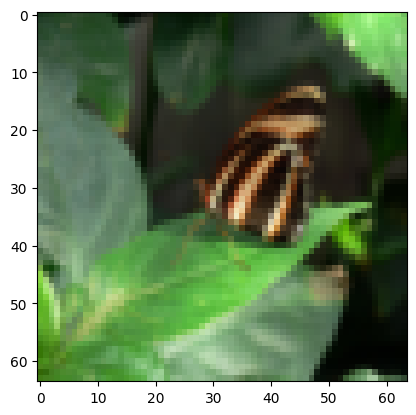

In [72]:
# Example of a picture that was wrongly classified.
index = 5, # Other options you could try: 6, 10, 11, 13
plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
print ("y = " + str(test_set_y[0,index]) + ", you predicted that it is a \"" + classes[int(logistic_regression_model['Y_prediction_test'][0,index])].decode("utf-8") +  "\" picture.")

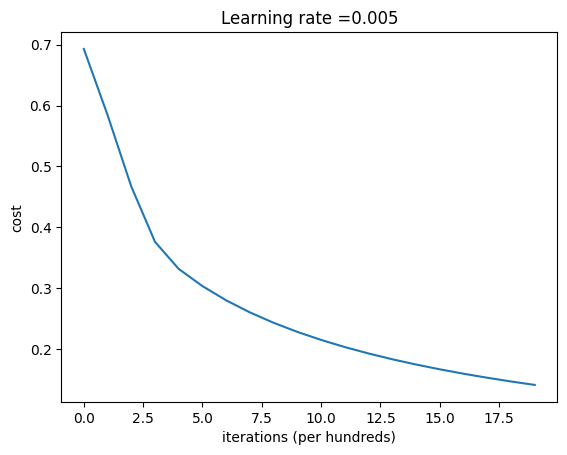

In [74]:
# Plot learning curve (with costs)
costs = np.squeeze(logistic_regression_model['cost'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()

**Interpretation**:
You can see the cost decreasing. It shows that the parameters are being learned. However, you see that you could train the model even more on the training set. Try to increase the number of iterations in the cell above and rerun the cells. You might see that the training set accuracy goes up, but the test set accuracy goes down. This is called overfitting. 

Training a model with learning rate:0.01

---------------------------------------------------------

Training a model with learning rate:0.001

---------------------------------------------------------

Training a model with learning rate:0.0001

---------------------------------------------------------



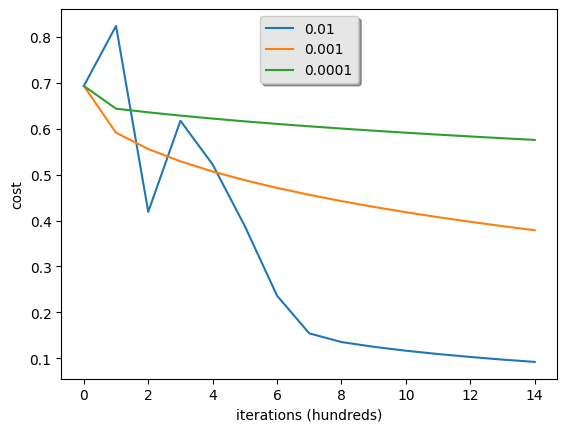

In [75]:
#Choose learning rate
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print("Training a model with learning rate:"+str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=lr, print_cost=False)
    print('\n'+"---------------------------------------------------------"+ '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["cost"]), label =str(models[str(lr)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

**Interpretation**: 
- Different learning rates give different costs and thus different predictions results.
- If the learning rate is too large (0.01), the cost may oscillate up and down. It may even diverge (though in this example, using 0.01 still eventually ends up at a good value for the cost). 
- A lower cost doesn't mean a better model. You have to check if there is possibly overfitting. It happens when the training accuracy is a lot higher than the test accuracy.
- In deep learning, we usually recommend that you: 
    - Choose the learning rate that better minimizes the cost function.
    - If your model overfits, use other techniques to reduce overfitting. (We'll talk about this in later videos.) 


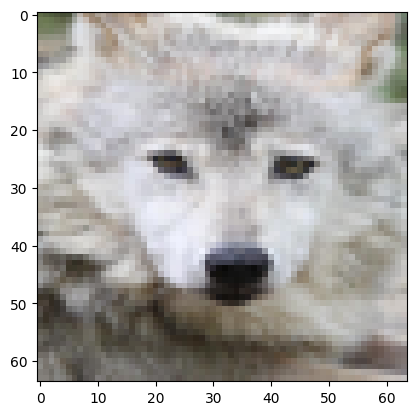

y = 1.0, your algorithm predicts a "cat" picture.


In [82]:
from PIL import Image

# Full image path
my_image = r"E:\Pyhton code\Data Sets\archive\Unsupervised Animal Classification\dataset\4651.jpg"

# Open and preprocess image
image = np.array(
    Image.open(my_image).resize((num_px, num_px))
)

plt.imshow(image)
plt.show()

# Normalize
image = image / 255.

# Flatten
image = image.reshape((1, num_px * num_px * 3)).T

# Predict
my_predicted_image = predict(
    logistic_regression_model["w"],
    logistic_regression_model["b"],
    image
)

print(
    "y = " +
    str(np.squeeze(my_predicted_image)) +
    ', your algorithm predicts a "' +
    classes[int(np.squeeze(my_predicted_image))].decode("utf-8") +
    '" picture.'
)